In [35]:
import mcstasscript as ms
import mcstastox as mx
import scipp as sc
from scipp.typing import VariableLike
import scipp as sc
import matplotlib.pyplot as plt
from scippneutron.conversion.graph.beamline import beamline
import numpy as np

import os
import sys 
sys.path.append("/Users/bb24144/Documents/McStas/reduction_plet/trex_data_reduction")
from trex_reduction import inelastic
from trex_reduction import produce_trex_event_object


parent = os.path.dirname(os.getcwd())

cspec_source_samp = {'source_name': "ESS_Source", 
                     'sample_name': "Sample"}

let_source_samp = {'source_name': "SourceMantid", 
                     'sample_name': "iso_samp"}

In [36]:
exp_folder = "CSPEC_benz_1e11"
file_path = os.path.join(parent, "runs", exp_folder)

with mx.Read(file_path) as loaded_data:
    scipp_object = loaded_data.export_scipp_simple(**cspec_source_samp)
    
data = ms.load_data(file_path)

In [37]:
scipp_object

<scipp.DataArray>
Dimensions: Sizes[events:1518992, ]
Coordinates:
* position                  vector3              [m]  (events)  [(3.584, 1.03934, 161.357), (3.05638, -0.343067, 162.206), ..., (3.82267, -1.16652, 160.573), (2.38533, 0.274512, 162.82)]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.11201, 0.112643, ..., 0.142001, 0.135132]
Data:
                            float64         [counts]  (events)  [1.02522e-07, 2.10907e-21, ..., 0.00917385, 3.78615e-05]

Skipped plotting Banana_1 as it contains event data.


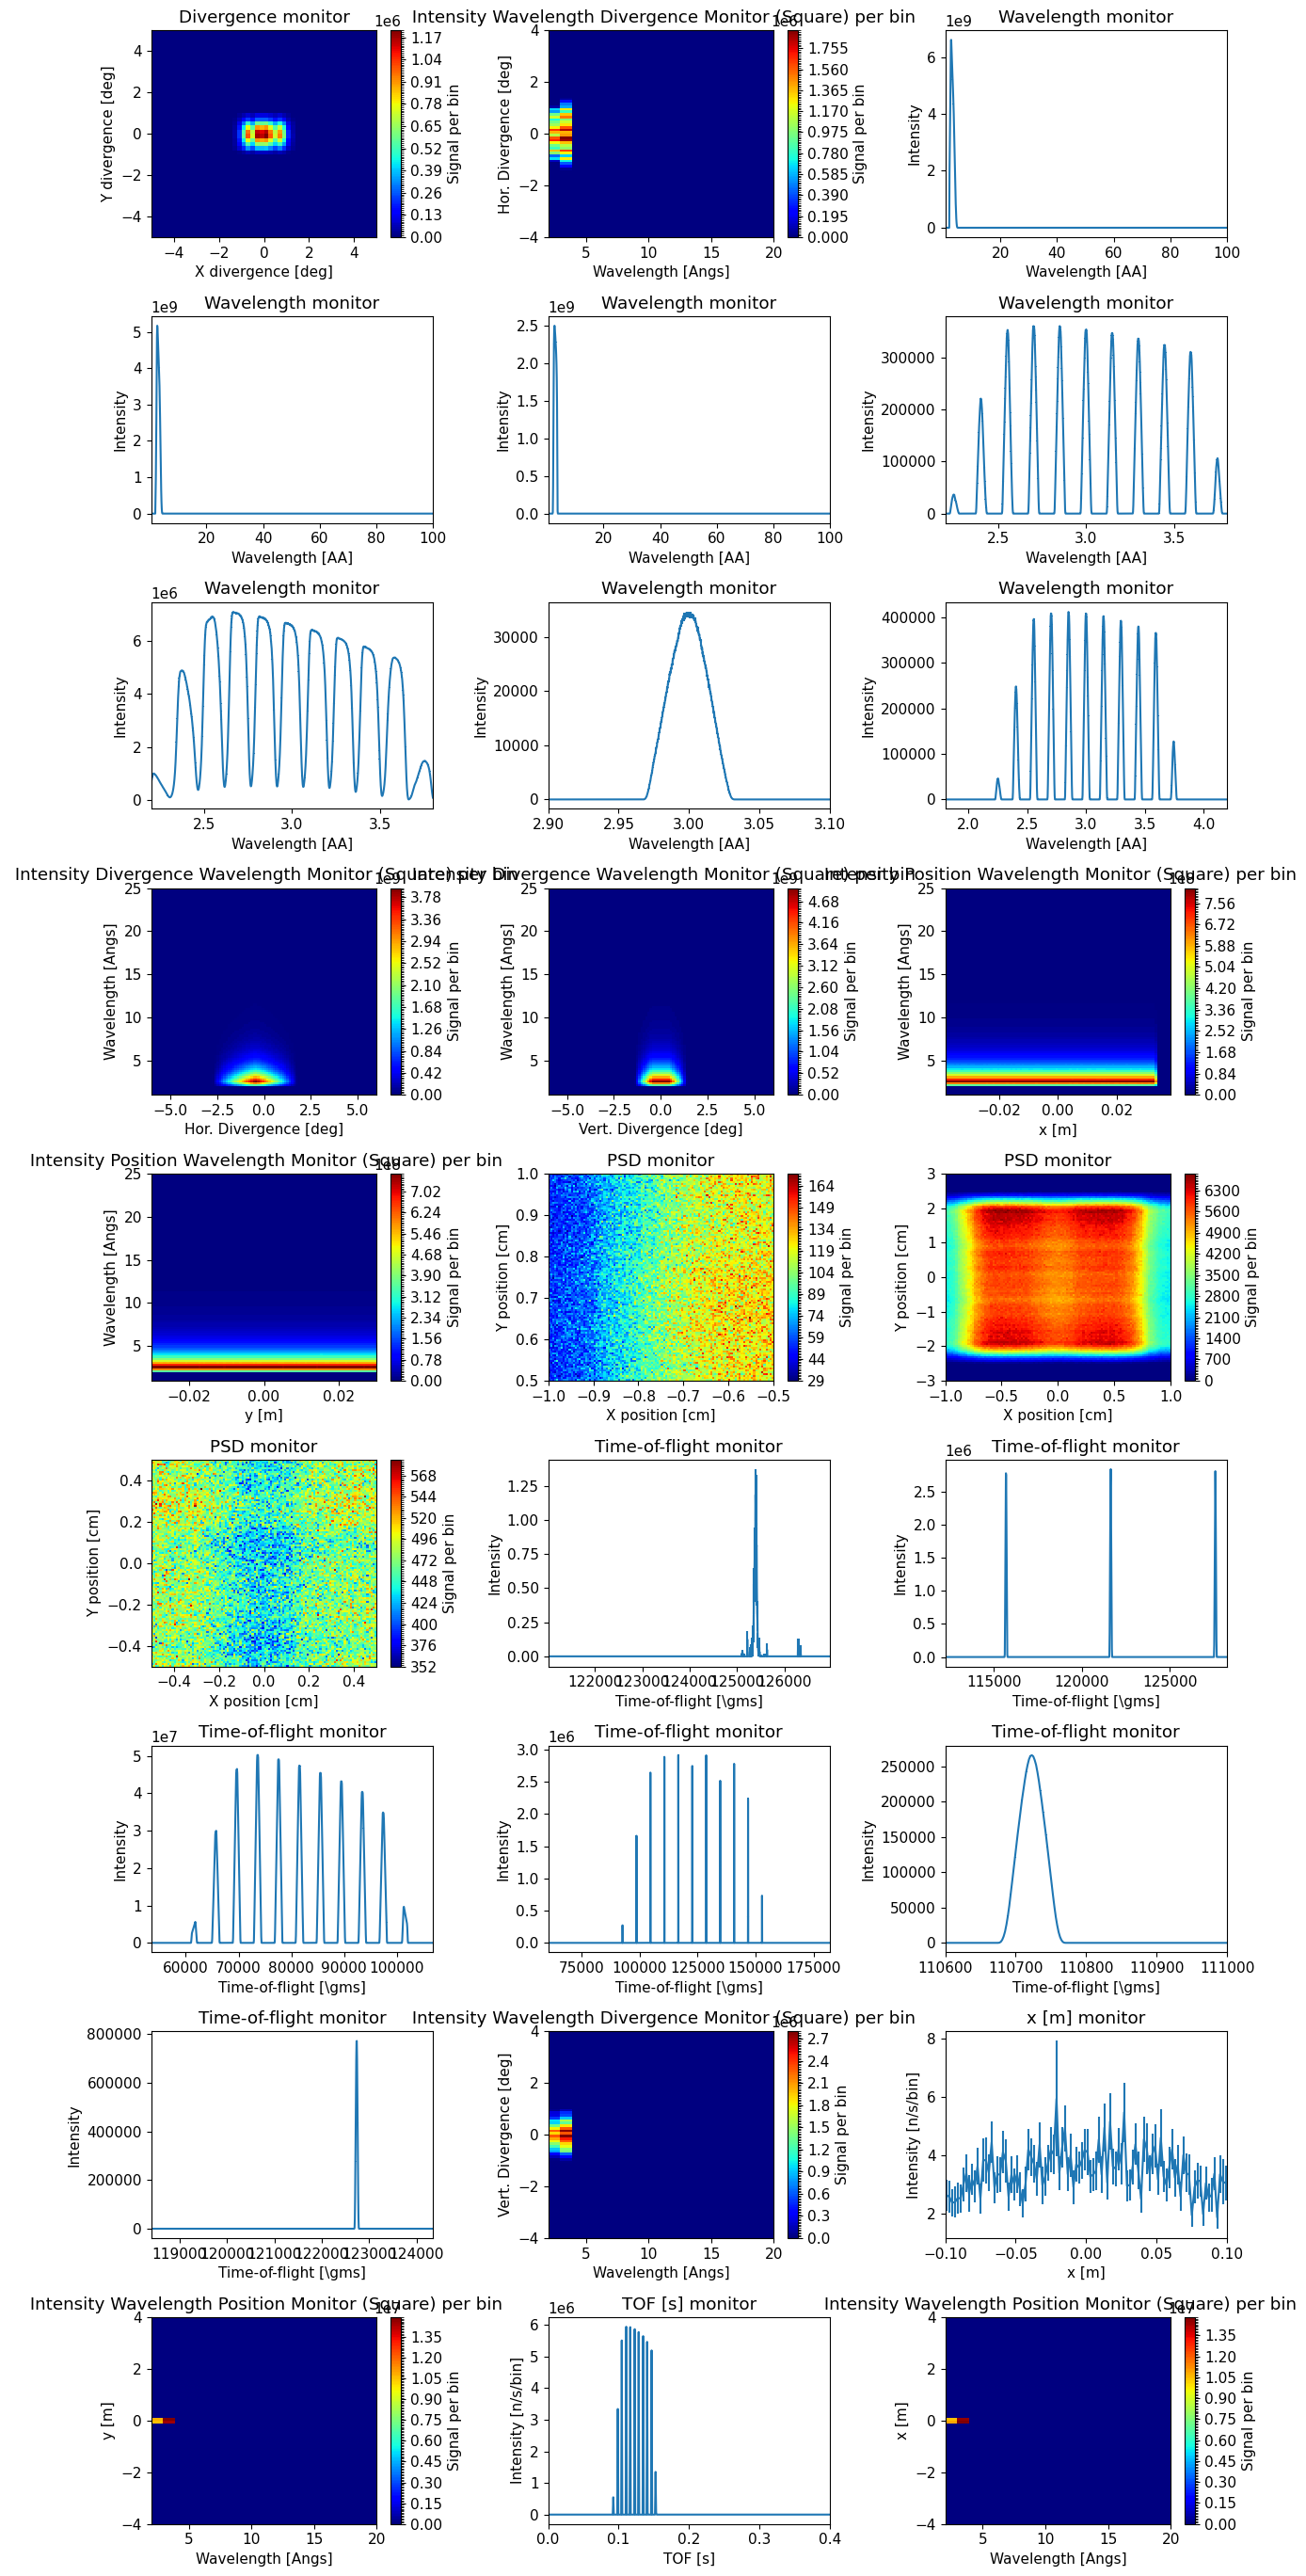

In [38]:
ms.make_sub_plot(data)

In [39]:
sys.path.append("/Users/bb24144/Documents/McStas/let_scipp/trex_data_reduction")
from trex_reduction import inelastic
from trex_reduction import produce_trex_event_object
from scippneutron.conversion.graph.beamline import beamline

from scipy.ndimage import label

In [40]:
def _calc_pulse_tof_centroid(tof_monitor,threshold=0, to_s=1e-6):
    # Assumes all pulses are evenly spaced in xaxis - but isn't bin data??? confirm this
    # Confirm correct way to axis tof data - is xaxis correct????? 
    mask = tof_monitor.Intensity != threshold
    labels, num_features = label(mask)
    weighted_sum = np.bincount(labels, weights=tof_monitor.xaxis * tof_monitor.Intensity)[1:]
    weight_total = np.bincount(labels, weights=tof_monitor.Intensity)[1:]

    coms = weighted_sum / weight_total * to_s
    return coms


# def _assign_time_on_monitor(event_object, pulse_centroids, gap = 0):
#     """ """
#     # Binning for assigning time on monitor
#     # Ideally also need to calculate time between monitor and sample to calc inf energy cut offs for each pulse - but this is a start

#     edges = np.concatenate([pulse_centroids-gap, [1e25]]) # scipp gets upset with np.inf? 
#     print(edges)
#     time_on_monitor_edges = sc.array(dims=['tof'], values=edges, unit='s')
#     binned = event_object.bin(tof=time_on_monitor_edges)


#     binned.coords['time_on_monitor'] = sc.array(
#         dims=['tof'], values=pulse_centroids-gap, unit='s'
#     )

#     binned.bins.coords['time_on_monitor'] = sc.bins_like(
#         binned, binned.coords['time_on_monitor']
#     )

#     unbinned = binned.bins.constituents['data']
#     return unbinned

def _assign_time_on_monitor(event_object, pulse_centroids, gap = 0):
    original_tof = event_object.coords['tof'].values
    bin_indices = np.searchsorted(pulse_centroids - gap, original_tof, side='right') - 1
    bin_indices = np.clip(bin_indices, 0, len(pulse_centroids) - 1)
    tom_mapped = (pulse_centroids - gap)[bin_indices]

    return tom_mapped


def produce_trex_event_object(event_object, data_path, monitor_name, to_s=1e-6, gap = 0):
    """ """

    with mx.Read(data_path) as loaded_data:
        monitor_position = loaded_data.get_global_component_coordinates(monitor_name)

    data = ms.load_data(data_path)
    monitor = ms.name_search(monitor_name, data)

    event_object.coords["monitor_position"] = sc.vector(
        value=monitor_position, unit="m"
    )

    centroids = _calc_pulse_tof_centroid(monitor)
    assigned_time_on_monitor = _assign_time_on_monitor(event_object, centroids, gap=gap)
    
    event_object.coords['time_on_monitor'] = sc.array(dims=event_object.dims, values=assigned_time_on_monitor, unit='s')


    return event_object


In [41]:
2.86e-3

0.00286

In [42]:

# Load event data into scipp 
event_object = scipp_object
# McStas provides absolute time, not time of flight
event_object.coords["tof"] = event_object.coords["t"] + sc.scalar(2.86e-3/2, unit = 's')
# Add additional information required for inelastic scattering
gap = 0
event_object = produce_trex_event_object(event_object, file_path, "TOF_Sample_AllLambda", gap = gap)
event_object

<scipp.DataArray>
Dimensions: Sizes[events:1518992, ]
Coordinates:
* monitor_position          vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* position                  vector3              [m]  (events)  [(3.584, 1.03934, 161.357), (3.05638, -0.343067, 162.206), ..., (3.82267, -1.16652, 160.573), (2.38533, 0.274512, 162.82)]
* sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
* source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.11201, 0.112643, ..., 0.142001, 0.135132]
* time_on_monitor           float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
* tof                       float64              [s]  (events)  [0.11344, 0.114073, ..., 0.143431, 0.136562]
Data:
                            float64         [counts]  (events)  [1.02522e-07, 2.10907e-21, ..., 0.00917385, 3.78615e-05]

In [43]:
monitor = ms.name_search("TOF_Sample_AllLambda", data)

centroids = _calc_pulse_tof_centroid(monitor)

In [44]:
centroids

array([0.09269959, 0.09870844, 0.10471575, 0.110723  , 0.11672966,
       0.12273672, 0.12874345, 0.13475043, 0.14075725, 0.14676423,
       0.15277264])

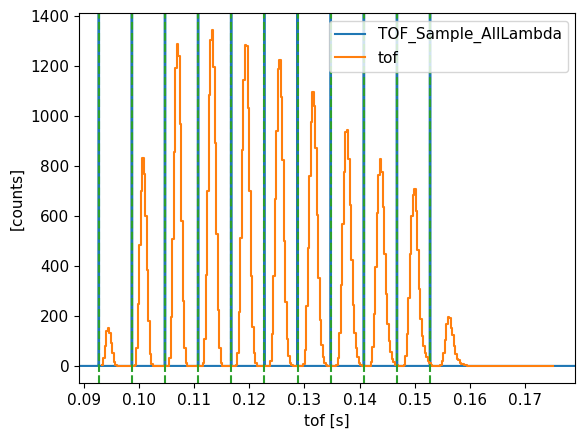

In [45]:

fig, ax = plt.subplots()
ax.plot(monitor.xaxis / 1e6, monitor.Intensity)
# (event_object.hist(time_on_monitor=100)).plot(ax=ax, linestyle='-', color='tab:blue')
(event_object.hist(tof=300)).plot(ax=ax, linestyle='-', color='tab:orange')

for i in centroids:
    ax.axvline(i-gap , color='tab:green', linestyle='--')
ax.legend(["TOF_Sample_AllLambda", 'tof'])

plt.show()


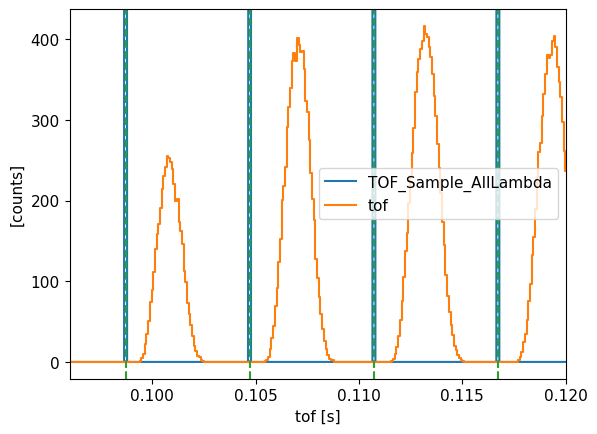

In [46]:

fig, ax = plt.subplots()
ax.plot(monitor.xaxis / 1e6, monitor.Intensity)
# (event_object.hist(time_on_monitor=100)).plot(ax=ax, linestyle='-', color='tab:blue')
(event_object.hist(tof=1000)).plot(ax=ax, linestyle='-', color='tab:orange')

ax.set_xlim(0.096,0.12)
ax.legend(["TOF_Sample_AllLambda", 'tof'])
for i in centroids:
    ax.axvline(i-gap , color='tab:green', linestyle='--')

plt.show()


In [47]:
qens_graph = {**beamline(scatter=True), **inelastic}

In [48]:

event_object = event_object.transform_coords("dE", graph=qens_graph)
event_object = event_object.transform_coords("mag_Q", graph=qens_graph)
event_object = event_object.transform_coords("two_theta", graph=qens_graph)
event_object

# event_object = event_object.transform_coords("dE", graph=qens_graph)
# event_object = event_object.transform_coords("mag_Q", graph=qens_graph)
# event_object = event_object.transform_coords("two_theta", graph=qens_graph)

# event_object

<scipp.DataArray>
Dimensions: Sizes[events:1518992, ]
Coordinates:
  L1                        float64              [m]  ()  159.954
  L2                        float64              [m]  (events)  [3.80212, 3.50151, ..., 3.57341, 3.57341]
  Lm                        float64              [m]  ()  159.954
  Q                         vector3           [1/Å]  (events)  [(-1.86306, -0.868312, 1.47398), (-1.25905, -0.0489323, 1.22625), ..., (-2.03778, 0.427849, 1.43647), (-1.75145, -0.632093, -0.628967)]
* dE                        float64            [meV]  (events)  [0.675561, 5.19805, ..., -2.58702, -12.9827]
  incident_beam             vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  kf                        vector3           [1/Å]  (events)  [(1.87386, 0.868318, 0.820431), (1.26985, 0.0489374, 1.06817), ..., (2.04628, -0.427845, 0.368373), (1.76033, 0.632097, 2.51426)]
  ki                        vector3           [1/Å]  (events)  [(0.0108034, 5.13289e-06, 2.29442), (0.0108034, 5.13289e-06, 2.29442), ..., (0.00849818, 4.03765e-06, 1.80484), (0.008877, 4.21764e-06, 1.8853)]
* mag_Q                     float64           [1/Å]  (events)  [2.52934, 1.7582, ..., 2.52963, 1.96538]
  mag_kf                    float64           [1/Å]  (events)  [2.22226, 1.66009, ..., 2.12274, 3.13366]
  mag_ki                    float64           [1/Å]  (events)  [2.29444, 2.29444, ..., 1.80486, 1.88532]
  monitor_beam              vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  monitor_position          vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  position                  vector3              [m]  (events)  [(3.584, 1.03934, 161.357), (3.05638, -0.343067, 162.206), ..., (3.82267, -1.16652, 160.573), (2.38533, 0.274512, 162.82)]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  scattered_beam            vector3              [m]  (events)  [(3.20603, 1.48563, 1.4037), (2.67841, 0.10322, 2.25301), ..., (3.4447, -0.720233, 0.620119), (2.00736, 0.7208, 2.86709)]
  source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.11201, 0.112643, ..., 0.142001, 0.135132]
  time_on_monitor           float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
  time_on_sample            float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
  tof                       float64              [s]  (events)  [0.11344, 0.114073, ..., 0.143431, 0.136562]
* two_theta                 float64            [rad]  (events)  [1.19169, 0.869563, ..., 1.39349, 0.638317]
  unit_kf                   vector3  [dimensionless]  (events)  [(0.843223, 0.390736, 0.369188), (0.764929, 0.0294788, 0.643439), ..., (0.963982, -0.201554, 0.173537), (0.561749, 0.201712, 0.802341)]
  unit_ki                   vector3  [dimensionless]  ()  (0.00470849, 2.2371e-06, 0.999989)
  vf                        float64            [m/s]  (events)  [1399.18, 1045.23, ..., 1336.52, 1973.02]
  vi                        float64            [m/s]  (events)  [1444.63, 1444.63, ..., 1136.38, 1187.04]
Data:
                            float64         [counts]  (events)  [1.02522e-07, 2.10907e-21, ..., 0.00917385, 3.78615e-05]

In [49]:
event_object

<scipp.DataArray>
Dimensions: Sizes[events:1518992, ]
Coordinates:
  L1                        float64              [m]  ()  159.954
  L2                        float64              [m]  (events)  [3.80212, 3.50151, ..., 3.57341, 3.57341]
  Lm                        float64              [m]  ()  159.954
  Q                         vector3           [1/Å]  (events)  [(-1.86306, -0.868312, 1.47398), (-1.25905, -0.0489323, 1.22625), ..., (-2.03778, 0.427849, 1.43647), (-1.75145, -0.632093, -0.628967)]
* dE                        float64            [meV]  (events)  [0.675561, 5.19805, ..., -2.58702, -12.9827]
  incident_beam             vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  kf                        vector3           [1/Å]  (events)  [(1.87386, 0.868318, 0.820431), (1.26985, 0.0489374, 1.06817), ..., (2.04628, -0.427845, 0.368373), (1.76033, 0.632097, 2.51426)]
  ki                        vector3           [1/Å]  (events)  [(0.0108034, 5.13289e-06, 2.29442), (0.0108034, 5.13289e-06, 2.29442), ..., (0.00849818, 4.03765e-06, 1.80484), (0.008877, 4.21764e-06, 1.8853)]
* mag_Q                     float64           [1/Å]  (events)  [2.52934, 1.7582, ..., 2.52963, 1.96538]
  mag_kf                    float64           [1/Å]  (events)  [2.22226, 1.66009, ..., 2.12274, 3.13366]
  mag_ki                    float64           [1/Å]  (events)  [2.29444, 2.29444, ..., 1.80486, 1.88532]
  monitor_beam              vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  monitor_position          vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  position                  vector3              [m]  (events)  [(3.584, 1.03934, 161.357), (3.05638, -0.343067, 162.206), ..., (3.82267, -1.16652, 160.573), (2.38533, 0.274512, 162.82)]
  sample_position           vector3              [m]  ()  (0.37797, -0.446287, 159.953)
  scattered_beam            vector3              [m]  (events)  [(3.20603, 1.48563, 1.4037), (2.67841, 0.10322, 2.25301), ..., (3.4447, -0.720233, 0.620119), (2.00736, 0.7208, 2.86709)]
  source_position           vector3              [m]  ()  (0, 0, 0)
* t                         float64              [s]  (events)  [0.11201, 0.112643, ..., 0.142001, 0.135132]
  time_on_monitor           float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
  time_on_sample            float64              [s]  (events)  [0.110723, 0.110723, ..., 0.140757, 0.13475]
  tof                       float64              [s]  (events)  [0.11344, 0.114073, ..., 0.143431, 0.136562]
* two_theta                 float64            [rad]  (events)  [1.19169, 0.869563, ..., 1.39349, 0.638317]
  unit_kf                   vector3  [dimensionless]  (events)  [(0.843223, 0.390736, 0.369188), (0.764929, 0.0294788, 0.643439), ..., (0.963982, -0.201554, 0.173537), (0.561749, 0.201712, 0.802341)]
  unit_ki                   vector3  [dimensionless]  ()  (0.00470849, 2.2371e-06, 0.999989)
  vf                        float64            [m/s]  (events)  [1399.18, 1045.23, ..., 1336.52, 1973.02]
  vi                        float64            [m/s]  (events)  [1444.63, 1444.63, ..., 1136.38, 1187.04]
Data:
                            float64         [counts]  (events)  [1.02522e-07, 2.10907e-21, ..., 0.00917385, 3.78615e-05]

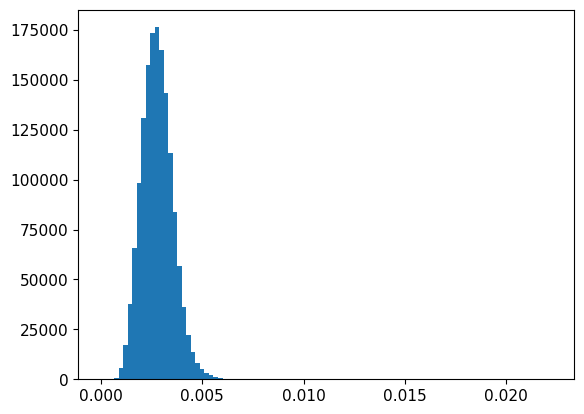

In [50]:
plt.hist(event_object.coords['tof'].values - event_object.coords['time_on_monitor'].values, bins=100)
plt.show()

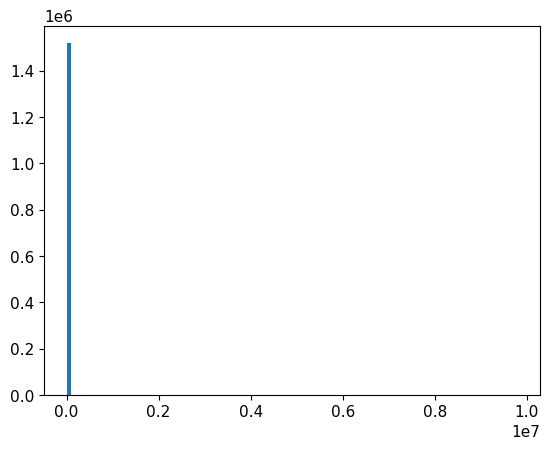

In [51]:
plt.hist(3.5 / (event_object.coords['tof'].values - event_object.coords['time_on_monitor'].values), bins=100)
plt.show()

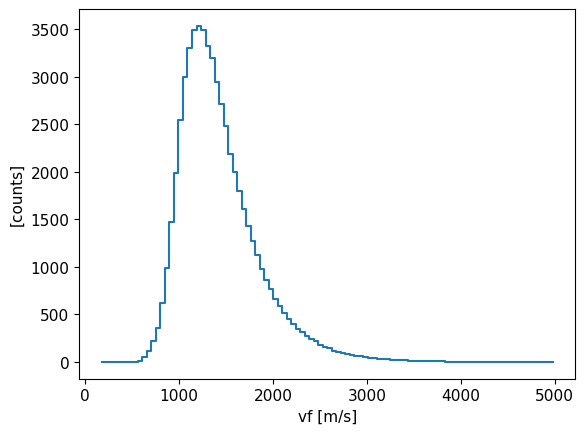

In [52]:
fig, ax = plt.subplots()
mask = event_object.coords['vf'] < sc.scalar(5000, unit=event_object.coords['vf'].unit)
event_object[mask].hist(vf=100).plot(ax=ax, linestyle='-', color='tab:blue')
plt.show()

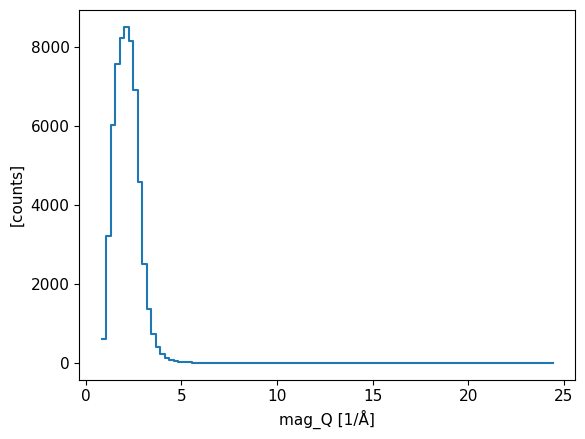

In [53]:
fig, ax = plt.subplots()
mask = event_object.coords['mag_Q'] < sc.scalar(25, unit=event_object.coords['mag_Q'].unit)
event_object[mask].hist(mag_Q=100).plot(ax=ax, linestyle='-', color='tab:blue')
plt.show()

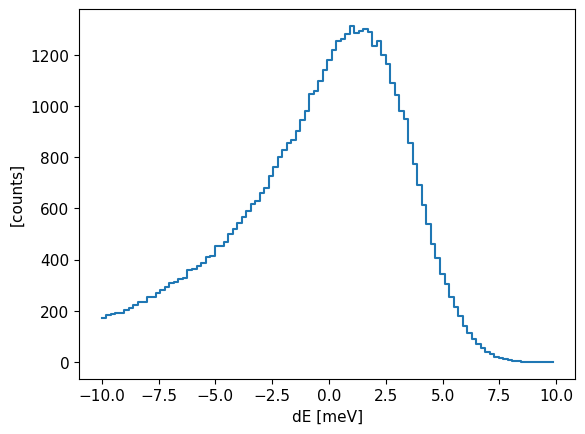

In [54]:
fig, ax = plt.subplots()
unit = event_object.coords['dE'].unit
mask = (event_object.coords['dE'] > sc.scalar(-10, unit=unit)) & (event_object.coords['dE'] < sc.scalar(10, unit=unit))
event_object[mask].hist(dE=100).plot(ax=ax, linestyle='-', color='tab:blue')
plt.show()